# Predicción de ingresos — UCI Adult Dataset
## Introducción al Aprendizaje Automático — 1er Cuatrimestre 2026
### 2do Entregable

**Grupo: 11**

| Integrante | e-mail |
|---|---|
| Silvia Fernández | silvia2484@gmail.com |
| Micaela Perez | mperez@estudiantes.unsam.edu.ar |

**Título del entregable:** Predicción de nivel de ingresos a partir de edad y nivel educativo — UCI Adult Dataset

**Enlace al conjunto de datos original:**  
https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data  
Documentación: https://archive.ics.uci.edu/ml/datasets/adult

Tambien el mismo se ecuentra en: https://www.kaggle.com/datasets/wenruliu/adult-income-dataset

##  comentarios del anterior tp

Que la variable sea tipo int no quiere decir que sea continua (puede ser categorica)
2.2 Elijan una (o maximo dos) acorde a su problema
2.3 Correlacion es una metrica muy buena para variables continuas, no tanto para categoricas

## Resumen

In [11]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [12]:
csv =r"adult.csv"

df_raw = pd.read_csv(csv, sep=",")

In [13]:
df_raw.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [14]:
# === a. DIMENSIONES ===
print("=== a. DIMENSIONES (dataset completo sin filtrar) ===")
print(f"Filas:    {df_raw.shape[0]}")
print(f"Columnas: {df_raw.shape[1]}")

# === b.FALTANTES ===
print("\n=== b. VALORES FALTANTES ===")
df_raw = df_raw.replace("?", np.nan)
faltantes = df_raw.isnull().sum()
faltantes_pct = (faltantes / len(df_raw) * 100).round(1)
resumen = pd.DataFrame({'Faltantes': faltantes, 'Porcentaje (%)': faltantes_pct})
print(resumen[resumen['Faltantes'] > 0])

# === c. TIPOS DE DATOS ===
print("\n=== c. TIPOS DE DATOS ===")
print(df_raw.dtypes.value_counts())
print(f"\nNuméricas: {(df_raw.dtypes != 'object').sum()}")
print(f"Categóricas: {(df_raw.dtypes == 'object').sum()}")


=== a. DIMENSIONES (dataset completo sin filtrar) ===
Filas:    48842
Columnas: 15

=== b. VALORES FALTANTES ===
                Faltantes  Porcentaje (%)
workclass            2799             5.7
occupation           2809             5.8
native-country        857             1.8

=== c. TIPOS DE DATOS ===
object    9
int64     6
Name: count, dtype: int64

Numéricas: 6
Categóricas: 9


In [15]:
df_raw.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'educational-num',
       'marital-status', 'occupation', 'relationship', 'race', 'gender',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income'],
      dtype='object')

In [16]:
print('edad menor del dataset: ', df_raw['age'].min())
print('edad mayor del dataset: ',df_raw['age'].max())

edad menor del dataset:  17
edad mayor del dataset:  90


1-Preschool 
2- 1st-4th       
3- 5th-6th       
4- 7th-8th  
5- 9th    
6 - 10th  
7 - 11th  
8 - 12th  
9 - HS-grad  
10 - Some - college
11 - Assoc-voc
12 - Assoc-acdm
13- Bachelors
14 - Masters
15 - Prof- scholl
16 - Doctorate


In [17]:
df_raw[['education','educational-num']].value_counts().sort_index()

education     educational-num
10th          6                   1389
11th          7                   1812
12th          8                    657
1st-4th       2                    247
5th-6th       3                    509
7th-8th       4                    955
9th           5                    756
Assoc-acdm    12                  1601
Assoc-voc     11                  2061
Bachelors     13                  8025
Doctorate     16                   594
HS-grad       9                  15784
Masters       14                  2657
Preschool     1                     83
Prof-school   15                   834
Some-college  10                 10878
Name: count, dtype: int64

## tp anterior

Registros tras filtrar rango 18-65 años: 46444

Distribución del target:
income_bin
<=50K    0.756
>50K     0.244
Name: proportion, dtype: float64


C:\Users\mikpz\AppData\Local\Temp\ipykernel_3080\3498223215.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


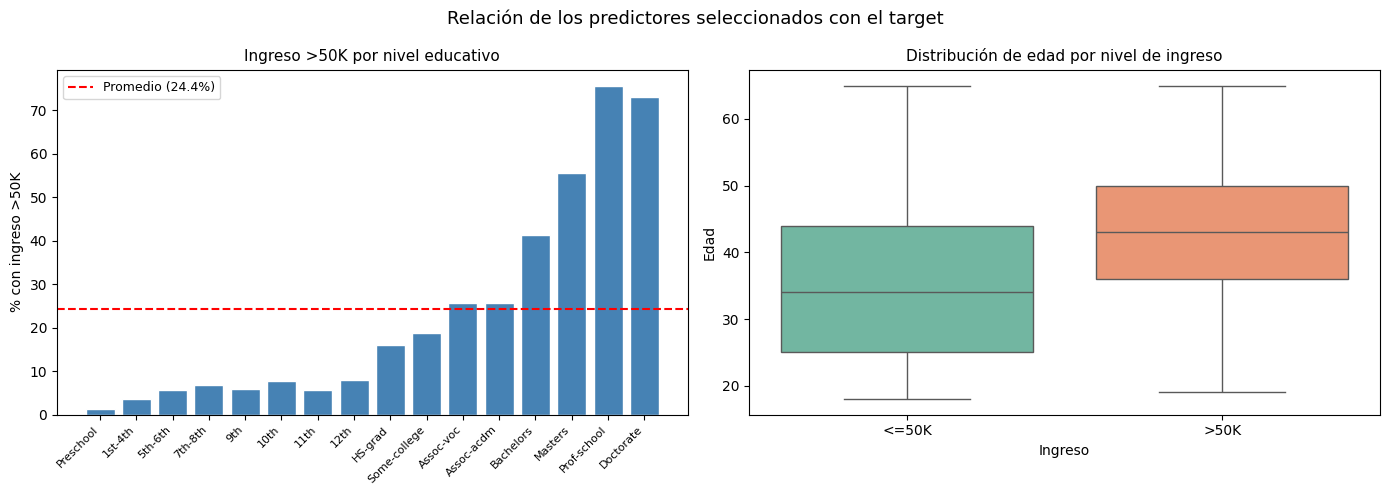

In [18]:
df = df_raw.copy()
df = df.dropna(subset=["age", "educational-num", "income"])
df = df[(df["age"] >= 18) & (df["age"] <= 65)]
df["income_bin"] = df["income"].apply(lambda x: 1 if ">50K" in x else 0) 

print(f"Registros tras filtrar rango 18-65 años: {df.shape[0]}")
print(f"\nDistribución del target:")
print(df["income_bin"].value_counts(normalize=True).rename({0: '<=50K', 1: '>50K'}).round(3))

# Orden educativo de menor a mayor
education_order = [
"Preschool", "1st-4th", "5th-6th", "7th-8th", "9th",
"10th", "11th", "12th", "HS-grad", "Some-college",
"Assoc-voc", "Assoc-acdm", "Bachelors", "Masters",
"Prof-school", "Doctorate"
]
edu_income = df.groupby("education")["income_bin"].mean().reindex(education_order).dropna()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Gráfico 1: % ingreso >50K por nivel educativo
promedio = df["income_bin"].mean() * 100
axes[0].bar(edu_income.index, edu_income.values * 100, color="steelblue", edgecolor="white")
axes[0].axhline(y=promedio, color="red", linestyle="--", label=f"Promedio ({promedio:.1f}%)")
axes[0].set_xticks(range(len(edu_income)))
axes[0].set_xticklabels(edu_income.index, rotation=45, ha="right", fontsize=8)
axes[0].set_ylabel("% con ingreso >50K")
axes[0].set_title("Ingreso >50K por nivel educativo", fontsize=11)
axes[0].legend(fontsize=9)
# Gráfico 2: distribución de edad por nivel de ingreso
sns.boxplot(
x="income", y="age", data=df,
palette="Set2", ax=axes[1]
)
axes[1].set_title("Distribución de edad por nivel de ingreso", fontsize=11)
axes[1].set_xlabel("Ingreso")
axes[1].set_ylabel("Edad")
plt.suptitle("Relación de los predictores seleccionados con el target", fontsize=13)
plt.tight_layout()
plt.show()


## educacion con relacion

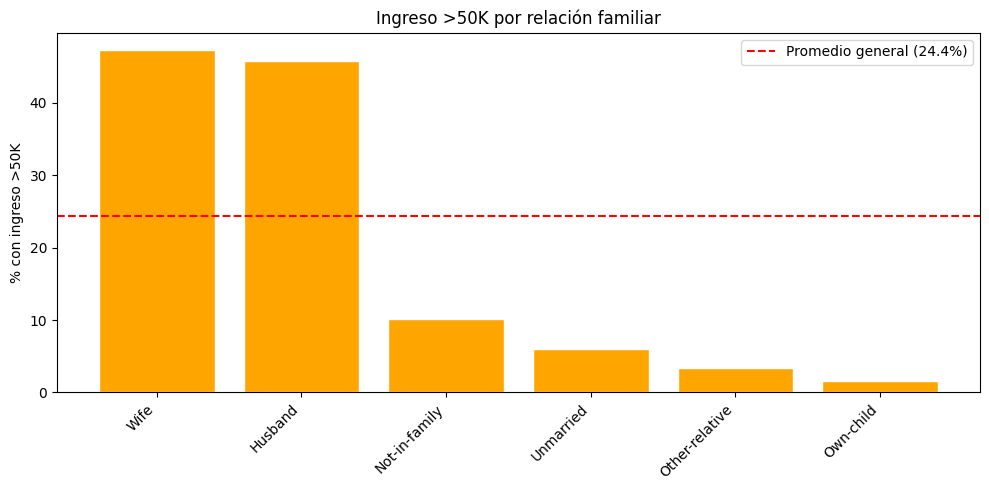

In [19]:
# % ingreso >50K por relación familiar
rel_income = (
    df.groupby("relationship")["income_bin"]
    .mean()
    .sort_values(ascending=False)
)

promedio = df["income_bin"].mean() * 100

plt.figure(figsize=(10, 5))

plt.bar(
    rel_income.index,
    rel_income.values * 100,
    color="orange",
    edgecolor="white"
)

plt.axhline(
    y=promedio,
    color="red",
    linestyle="--",
    label=f"Promedio general ({promedio:.1f}%)"
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("% con ingreso >50K")
plt.title("Ingreso >50K por relación familiar")
plt.legend()
plt.tight_layout()

plt.show()

In [20]:
def agrupar_educacion(x):
    if x in ["Preschool", "1st-4th", "5th-6th", "7th-8th", "9th", "10th", "11th", "12th"]:
        return "Bajo"
    elif x == "HS-grad":
        return "Secundario completo"
    elif x in ["Some-college", "Assoc-voc", "Assoc-acdm"]:
        return "Terciario/Técnico"
    elif x == "Bachelors":
        return "Universitario"
    elif x in ["Masters", "Prof-school", "Doctorate"]:
        return "Posgrado"
    else:
        return "Otro"
df["education_group"] = df["education"].apply(agrupar_educacion)
df["education_group"].value_counts()

education_group
Secundario completo    15180
Terciario/Técnico      14174
Universitario           7804
Bajo                    5392
Posgrado                3894
Name: count, dtype: int64

In [ ]:
def agrupar_relation(x):
    if x in ["Husband", "Wife"]:
        return "Married"
    elif x == "Not-in-family":
        return "Not-in-family"
    elif x == "Own-child":
        return "Own-child"
    elif x == "Unmarried":
        return "Unmarried"
    else:
        return "Other-relative"

df["relationship_group"] = df["relationship",'marital_'].apply(agrupar_relation)

df["relationship_group"].value_counts()

relationship_group
Married           21047
Not-in-family     11959
Own-child          7033
Unmarried          4980
Other-relative     1425
Name: count, dtype: int64

In [22]:
df['gender'].value_counts()

gender
Male      31145
Female    15299
Name: count, dtype: int64

In [25]:
df.head(10)

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income,income_bin,education_group,relationship_group
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K,0,Bajo,Own-child
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K,0,Secundario completo,Married
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K,1,Terciario/Técnico,Married
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K,1,Terciario/Técnico,Married
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K,0,Terciario/Técnico,Own-child
5,34,Private,198693,10th,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,<=50K,0,Bajo,Not-in-family
6,29,NaN,227026,HS-grad,9,Never-married,NaN,Unmarried,Black,Male,0,0,40,United-States,<=50K,0,Secundario completo,Unmarried
7,63,Self-emp-not-inc,104626,Prof-school,15,Married-civ-spouse,Prof-specialty,Husband,White,Male,3103,0,32,United-States,>50K,1,Posgrado,Married
8,24,Private,369667,Some-college,10,Never-married,Other-service,Unmarried,White,Female,0,0,40,United-States,<=50K,0,Terciario/Técnico,Unmarried
9,55,Private,104996,7th-8th,4,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,10,United-States,<=50K,0,Bajo,Married


In [30]:
df['marital-status'].value_counts()

marital-status
Married-civ-spouse       21376
Never-married            15413
Divorced                  6478
Separated                 1510
Widowed                   1029
Married-spouse-absent      602
Married-AF-spouse           36
Name: count, dtype: int64

In [29]:
df[['marital-status','relationship_group']].value_counts()

marital-status         relationship_group
Married-civ-spouse     Married               21013
Never-married          Not-in-family          7004
                       Own-child              6207
Divorced               Not-in-family          3507
                       Unmarried              2347
Never-married          Unmarried              1322
                       Other-relative          880
Separated              Unmarried               664
                       Not-in-family           623
Widowed                Not-in-family           493
                       Unmarried               468
Divorced               Own-child               453
Married-spouse-absent  Not-in-family           309
Married-civ-spouse     Other-relative          198
Married-spouse-absent  Unmarried               179
Divorced               Other-relative          171
Separated              Own-child               145
Married-civ-spouse     Own-child               142
Separated              Other-relative   

In [54]:
def situacion_persona(row):

    marital = row["marital-status"]
    relation = row["relationship"]

        
    if relation == "Own-child": # no interesa si se caso , divorcio o enviudo
            return 'Hijo/a dependitente'
    
    elif marital in ["Married-civ-spouse", "Married-AF-spouse"]:
        return "Casado"

    elif marital in ["Divorced", "Separated",'Never-married','Married-spouse-absent'] :
            return "Separado/Divorciado"

    elif marital == "Widowed":
            return "Viudo/a"

    else:
        return "Otro"

df["situacion_persona"] = df.apply(situacion_persona, axis=1)

In [ ]:
#df[['situacion_persona','marital-status','relationship']].value_counts()

situacion_persona    marital-status         relationship  
Casado               Married-civ-spouse     Husband           18748
Separado/Divorciado  Never-married          Not-in-family      7004
Hijo/a dependitente  Never-married          Own-child          6207
Separado/Divorciado  Divorced               Not-in-family      3507
                                            Unmarried          2347
Casado               Married-civ-spouse     Wife               2265
Separado/Divorciado  Never-married          Unmarried          1322
                                            Other-relative      880
                     Separated              Unmarried           664
                                            Not-in-family       623
Viudo/a              Widowed                Not-in-family       493
                                            Unmarried           468
Hijo/a dependitente  Divorced               Own-child           453
Separado/Divorciado  Married-spouse-absent  Not-in-family

In [55]:
df['situacion_persona'].value_counts()

situacion_persona
Casado                 21269
Separado/Divorciado    17137
Hijo/a dependitente     7033
Viudo/a                 1005
Name: count, dtype: int64

income_bin                     0     1
situacion_persona   gender            
Casado              Female  0.54  0.46
                    Male    0.55  0.45
Hijo/a dependitente Female  0.99  0.01
                    Male    0.98  0.02
Separado/Divorciado Female  0.94  0.06
                    Male    0.89  0.11
Viudo/a             Female  0.94  0.06
                    Male    0.78  0.22

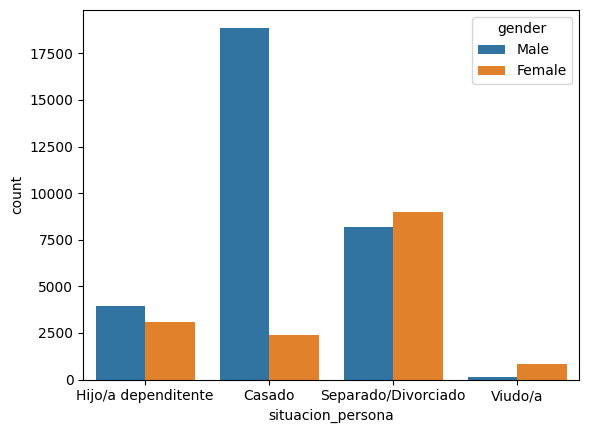

In [56]:
sns.countplot(
    data=df,
    x="situacion_persona",
    hue="gender"
)

pd.crosstab(
    [df["situacion_persona"], df["gender"]],
    df["income_bin"],
    normalize="index"
).round(2)